In [33]:
import os

In [34]:
from qiskit_aer.primitives import Estimator
from qiskit_aer import AerSimulator 
import numpy as np
from qiskit.quantum_info import  random_clifford, state_fidelity 
from tomography import SelfGuidedTomography, Mean_Direct_Fidelity, NearSparseTomography, NearSparseTomography_v2

In [35]:
from qiskit_aer.noise import NoiseModel, depolarizing_error 
error_1 = depolarizing_error( 1e-3, 1 )
error_2 = depolarizing_error( 5e-3, 2 )
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(error_1, ['h', 's', 'sd', 'x'])
noise_model.add_all_qubit_quantum_error(error_2, ['cx'])

In [36]:
NQs = [2,3,4]
L = len(NQs)
N = 10 
shots = 1000
num_iter = 10 

simulator =Estimator(backend_options={'shots':shots,
                                    'method':"stabilizer",
                                    'noise_model':noise_model,
                                    },
                    transpile_options={'optimization_level':0},
                    ) 

In [37]:
from joblib import Parallel, delayed

def simulate( NQ, simulator=simulator ):

    d = 2**NQ

    Omega  = random_clifford( NQ ).to_circuit() 

    #####
    qasm = AerSimulator(method='density_matrix',
                        noise_model=noise_model)
    Omega_density = Omega.copy()
    Omega_density.save_density_matrix()
    OmegaM_noisy = np.array( qasm.run(Omega_density).result().data()['density_matrix'] )
    #####

    # I_th = lambda x: 1 - np.vdot( x, OmegaM_noisy@x )/(np.linalg.norm( x ))**2

    MDF = Mean_Direct_Fidelity(NQ)

    stop_measuring = lambda x : ( np.linalg.norm( list( x.values() ) )**2 > 0.95 )

    I_ex = lambda x : 1 - MDF.MeanFidelity(1,  
                                        2*NQ**2,  
                                        x,  
                                        Omega, 
                                        simulator, 
                                        truncation= None, 
                                        stop_measuring = stop_measuring, 
                                        )

    def I_th( x ):

        x = x/np.linalg.norm( x )
        Is = []
        I_1 = 1 - np.vdot( x, OmegaM_noisy@x )
        Is.append( I_1 )

        F = 1- I_ex( x )
        FF = np.max( [ np.min( [(d*F-1)/(d-1), 1]), 0 ] )
        print(FF)
        
        rho_white = FF * np.outer( x, x.conj() ) + (1-FF)*np.eye(d) /d
        rho_white = 0.5*rho_white+.5*rho_white.T.conj()
        rho_white = rho_white / np.trace( rho_white )
        I_2 = 1 - state_fidelity( rho_white , OmegaM_noisy, validate=False ) 
        Is.append( I_2 )

        # phi = NearSparseTomography( x, MDF=MDF )
        rho = NearSparseTomography_v2( x, MDF=MDF )
        rho = 0.5*rho + 0.5*rho.T.conj()
        rho = rho / np.trace( rho )
        I_3 = 1 - state_fidelity( rho, OmegaM_noisy, validate=False ) 
        Is.append( I_3 )

        return Is

    Fidelities = []
    Measures = []
    Last=[]
    Purity = []
    def callback( i, x ):
        Last.append(x)
        Fidelities.append( I_th(x) )
        Measures.append(len(MDF.Measures))
        Purity.append( np.sum(np.array(
                        list(MDF.Measures.values()))**2) )
        return None

    # first level 
    psi0 = np.random.rand(d) + 1j * np.random.rand(d)
    psi0 = psi0 / np.linalg.norm(psi0)
    guess = psi0 

    postprocessing = lambda x : NearSparseTomography( x, MDF=MDF )

    SelfGuidedTomography( I_ex, 
                            guess, 
                            num_iter=num_iter, 
                            callback = callback,
                            postprocessing = postprocessing,
                            ) 

    Results=[np.array(Fidelities), 
                np.array(Measures), 
                np.array(Last),
                np.array(Purity),
                OmegaM_noisy, ] 

    return Results  #j index the average over the Hilbert space 


In [38]:
# simulate(2, simulator )

In [39]:
iterator = np.repeat(NQs, N).flatten()

R = Parallel(n_jobs=-1, verbose=11)(delayed(simulate)(int(NQ)) for NQ in iterator) 

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done   2 out of  30 | elapsed:    5.7s remaining:  1.4min
[Parallel(n_jobs=-1)]: Done   5 out of  30 | elapsed:    5.9s remaining:   30.0s
[Parallel(n_jobs=-1)]: Done   8 out of  30 | elapsed:    6.7s remaining:   18.7s
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed:   14.1s remaining:   24.5s
[Parallel(n_jobs=-1)]: Done  14 out of  30 | elapsed:   19.1s remaining:   21.8s
[Parallel(n_jobs=-1)]: Done  17 out of  30 | elapsed:   20.3s remaining:   15.5s
[Parallel(n_jobs=-1)]: Done  20 out of  30 | elapsed:   23.6s remaining:   11.7s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:   56.9s remaining:   17.2s
[Parallel(n_jobs=-1)]: Done  26 out of  30 | elapsed:  1.0min remaining:    9.4s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  1.2min finished


In [40]:
np.sort( np.abs(R[-1][-1]).flatten() )

array([4.50882651e-20, 1.06908076e-19, 1.06908076e-19, 1.10356724e-19,
       1.10356724e-19, 1.10356724e-19, 1.13805371e-19, 1.79591844e-19,
       1.83928652e-19, 1.89991511e-19, 2.17728748e-19, 2.17728748e-19,
       2.38049426e-19, 2.46770921e-19, 2.64070278e-19, 2.70133137e-19,
       2.73585236e-19, 1.57709776e-18, 1.57709776e-18, 1.57709776e-18,
       1.57709776e-18, 1.57709776e-18, 1.57709776e-18, 1.87154986e-18,
       1.87154986e-18, 1.87154986e-18, 1.87154986e-18, 1.87154986e-18,
       1.87154986e-18, 1.87154986e-18, 1.87154986e-18, 3.17939919e-18,
       3.19094153e-18, 3.19094153e-18, 3.19094153e-18, 3.19094153e-18,
       3.19094153e-18, 3.19094153e-18, 3.19094153e-18, 3.19094153e-18,
       3.21405029e-18, 3.21666105e-18, 3.23091887e-18, 3.23091887e-18,
       3.24648702e-18, 3.25082383e-18, 3.26471897e-18, 3.33484225e-18,
       3.33829089e-18, 3.40010898e-18, 3.40010898e-18, 3.40528540e-18,
       3.55555569e-18, 3.55900434e-18, 3.55900434e-18, 3.55900434e-18,
      

In [41]:
Fids, Meas, _, Pury = [[[R[i + j * N][r] for i in range(N)] for j in range(len(NQs))]
                    for r in range(4)]

Fids = np.real(Fids)
Meas = np.array(Meas)

In [42]:
import matplotlib.pyplot as plt 

In [43]:
4**np.array(NQs),

(array([ 16,  64, 256], dtype=int32),)

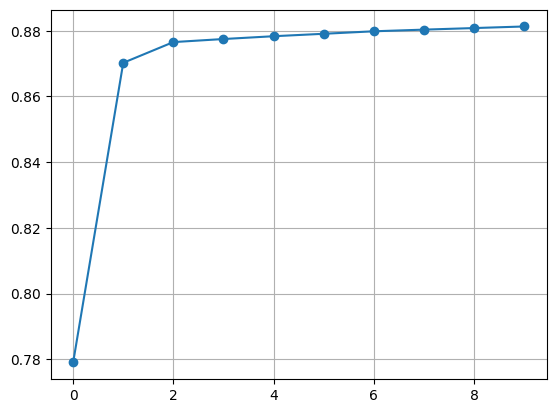

In [44]:
plt.plot( np.mean( Pury[2], axis=0 ), '-o' ) 
plt.grid() 

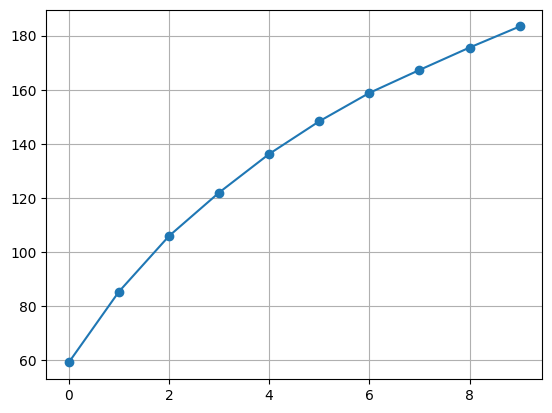

In [45]:
plt.plot( np.mean( Meas[2], axis=0 ), '-o' ) 
plt.grid() 

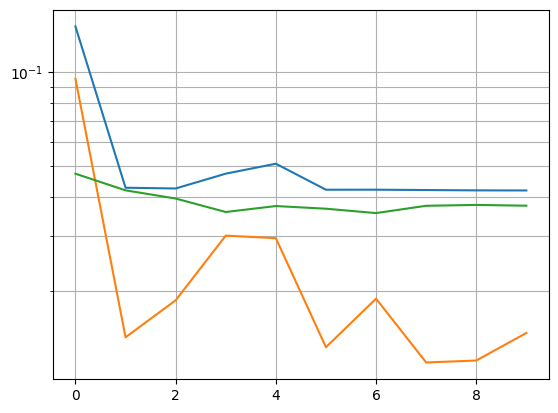

In [46]:
plt.semilogy( np.mean( Fids[-1], axis=0 ) ) 
plt.grid(which='both') 

In [47]:
# Save data. Ax order Fids and Meas are: [NQ, Nrun, Niter]

filename = "sgqt_for_mixed2.npz"

data = {
    "N": [N],
    "shots": [shots],
    "Niter": [num_iter],
    "NQs": NQs,
    "Fids": Fids,
    "Meas": Meas,
    "info": ["N, shots, and Niter are single integers in one array each.",
             "NQs is the array of number of qubits.",
             "Fids and Meas have shapes (len(NQs), N, Niter)"],
}

# Make directory "data" if not present
os.makedirs("data", exist_ok=True)

# Save
filepath = os.path.join("data", filename)
np.savez(filepath, **data)